# 1) Se está tratando de localizar, con mayor precisión, la raíz de 𝑓(𝑥) = x^(−2) − 𝑡𝑔(𝑥) queestá entre [ 0.5 , π/2) :


In [1]:
import numpy as np
import math as mt

def f_punto1(x):
    return np.float32( x**(-2) - np.tan(x))

def metodo_secante(x1, x2, eps, maxIter, f):
    ite = 0
    while ((ite <= maxIter) and np.abs(x1 - x2) > eps):
        x3 = np.float32( x2 - f(x2)*((x2 - x1)/(f(x2) - f(x1))))
        x1 = x2
        x2 = x3
        ite = ite + 1
    return ite

def metodo_Regula_Falsi(x1, x2, eps, maxIter, f):
    ite = 0
    x3 = np.float32( x2 - f(x2)*((x2 - x1)/(f(x2) - f(x1))))
    while (np.abs(f(x3)) > eps and ite <= maxIter):
        ite = ite + 1
        if f(x1)*f(x3) > 0:
            x1 = x3
        else:
            x2 = x3
        x3 = np.float32( x2 - f(x2)*((x2 - x1)/(f(x2) - f(x1))))
    if ite <= maxIter:
        return ite
    print("No converge")
    return False

eps = 1e-3
maxIte = 100
m_sec = metodo_secante( np.float32(0.5), np.float32(1.5), np.float32(eps), maxIte, f_punto1)
m_reg_fal = metodo_Regula_Falsi(0.5, 1.5, eps, maxIte, f_punto1)

print(f"Cantidad de iteraciones de Metodo Secante: {m_sec}")
print(f"Cantidad de iteraciones del Metodo R-Falsi: {m_reg_fal}")
print("La diferencia entre hambos metodos es que el metodo Secante converge más rapido que el metodo Regula Falsi")

Cantidad de iteraciones de Metodo Secante: 6
Cantidad de iteraciones del Metodo R-Falsi: 25
La diferencia entre hambos metodos es que el metodo Secante converge más rapido que el metodo Regula Falsi


# 2) Implemente el Método de Newton–Raphson en Python. Explique en cada caso que ocurre al aplicar el método en los siguientes casos:


In [1]:
#a
import numpy as np
import math as mt

def newton_raphson(x, eps, maxIte, f, df):
    ite = 0
    dif = 2*eps
    while (ite <= maxIte and dif > eps):
        x1 = np.float32(x - f(x)/df(x))
        dif = np.abs(x1 - x)
        ite += 1
        x = x1
    print(f"Iteracion: {ite}")
    if ite > maxIte:
        return "Diverge"
    return x1

def f_punto2a(x):
    return np.float32(x*(x - 1) * (x + 1))

def g_punto2a(x):
    return np.float32(3*x**2 - 1)

eps = 1e-03
maxIte = 100
x0 = np.sqrt(1/5)
print("Para el apartado a con f(X)= x^3 -x  con un valor inicial x0 = √(1/5)")
print(f"primera funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto2a, g_punto2a)}")

Para el apartado a con f(X)= x^3 -x  con un valor inicial x0 = √(1/5)
Iteracion: 13
primera funcion converge a: -1.4210854715202004e-14


In [9]:
#b
import numpy as np
import math as mt

def f_punto2b(x):
    return np.float32(x**3 - 2*x + 2)

def g_punto2b(x):
    return np.float32(3*x**2 - 2)

x0 = 0
print("Para el apartado a con f(X)= x^3 - 2x + 2  con un valor inicial x0 = 0")
print(f"segunda funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto2b, g_punto2b)}")

Para el apartado a con f(X)= x^3 - 2x + 2  con un valor inicial x0 = 0
Iteracion: 101
segunda funcion converge a: Diverge


# 3) Utilice su implementación del método de Newton-Raphson para encontrar las raíces de:


In [8]:
#i
import numpy as np
def f_punto3i(x):
    return np.float32(np.sin(x) - 1/2*np.sqrt(x))

def df_punto3i(x):
    return np.float32(np.cos(x) - 1/(4*np.sqrt(x)))

x0 = 3.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3i, df_punto3i)}")
x0 = 0.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3i, df_punto3i)}")
x0 = 0.05
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3i, df_punto3i)}")

Iteracion: 3
la funcion converge a: 2.284761428833008
Iteracion: 3
la funcion converge a: 0.2555122971534729
Iteracion: 2
la funcion converge a: nan


C:\Users\x\AppData\Local\Temp\ipykernel_6012\2846002300.py:4: RuntimeWarning: invalid value encountered in sqrt
  return np.float32(np.sin(x) - 1/2*np.sqrt(x))
C:\Users\x\AppData\Local\Temp\ipykernel_6012\2846002300.py:7: RuntimeWarning: invalid value encountered in sqrt
  return np.float32(np.cos(x) - 1/(4*np.sqrt(x)))


In [11]:
#ii
import numpy as np
def g_punto3ii(x):
    return np.float32(np.tan(x) - 0.5*x)

def dg_punto3ii(x):
    return np.float32((1/np.cos(x))**2 - 0.5)

x0 = 1
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, g_punto3ii, dg_punto3ii)}")
x0 = 3.3
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, g_punto3ii, dg_punto3ii)}")
x0 = 1.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, g_punto3ii, dg_punto3ii)}")

Iteracion: 5
la funcion converge a: 0.0
Iteracion: 7
la funcion converge a: 23.476961135864258
Iteracion: 8
la funcion converge a: 0.0


In [18]:
#iii
def h(x):
    return np.float32(x**10 - 1)
def dh(x):
    return np.float32(10*x**9)

x0 = 1.2
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, h, dh)}")
x0 = 0.7
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, h, dh)}")
x0 = 0.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, h, dh)}")

Iteracion: 5
la funcion converge a: 1.0
Iteracion: 15
la funcion converge a: 1.0000001192092896
Iteracion: 42
la funcion converge a: 1.0


In [6]:
# iv

def f_punto3iv(x):
    return np.float32(x**3 - 5 * x**2 + 7 * x - 3)

def df_punto3iv(x):
    return np.float32(3 * x**2 - 10 * x + 7)

x0 = 1.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3iv, df_punto3iv)}")
x0 = 0.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3iv, df_punto3iv)}")
x0 = 3.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3iv, df_punto3iv)}")

Iteracion: 9
la funcion converge a: 1.0006529092788696
Iteracion: 10
la funcion converge a: 0.9993590712547302
Iteracion: 4
la funcion converge a: 2.999999761581421


In [7]:
# v
def f_punto3v(x):
    return np.float32(x**2 - x - 2.5)

def df_punto3v(x):
    return np.float32(2*x - 1)

x0 = 2.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3v, df_punto3v)}")
x0 = 1
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3v, df_punto3v)}")
x0 = -1.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3v, df_punto3v)}")

Iteracion: 3
la funcion converge a: 2.1583125591278076
Iteracion: 5
la funcion converge a: 2.1583123207092285
Iteracion: 3
la funcion converge a: -1.158312439918518


In [15]:
# vi
def f_punto3vi(x):
    return np.float32(x**(-2) - np.tan(x))

def df_punto3vi(x):
    return np.float32(-2 * x**(-3) - (1/np.cos(x))**2)

x0 = 0.05
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3vi, df_punto3vi)}")
x0 = 0.5
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3vi, df_punto3vi)}")
x0 = 1.572
print(f"la funcion converge a: {newton_raphson(np.float32(x0), np.float32(eps), maxIte, f_punto3vi, df_punto3vi)}")


Iteracion: 10
la funcion converge a: 0.8952060341835022
Iteracion: 4
la funcion converge a: 0.8952059745788574
Iteracion: 13
la funcion converge a: 3.23675537109375


# 4) La ecuación 𝑥^2 − 2𝑥 − 3 = 0 tiene dos raíces, en x = -1 y en x = 3.


In [16]:
import numpy as np
def f_punto4(x):
    return np.float32(x**2 - 2 * x - 3)

def g1(x):
    return np.float32(np.sqrt(2 * x + 3))

def g2(x):
    return np.float32((x**2 - 3) / 2)

def g3(x):
    return np.float32(3 / (x - 2))

def Punto_Fijo(x, eps, maxIte, g):
    ite = 0
    x1 = x + 2 * eps
    div = 2*eps
    while (ite <= maxIte and div > eps):
        x1 = g(x)
        ite += 1
        div = np.abs(x1-x)
        x = x1
    print(f"Termino con {ite} iteraciones")
    print(x1)
    if ite > maxIte:
        return "Diverge"
    return x1

x0 = -4
eps = 1e-03
maxIte = 100
print(f"con x = {x0}")
print(f"la funcion G1 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g1)}")
print("- - - -")
print(f"la funcion G2 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g2)}")
print("- - - -")
print(f"la funcion G3 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g3)}")
print(" / - - - - - - - - /")


con x = -4
Termino con 1 iteraciones
nan
la funcion G1 converge a: nan
- - - -
Termino con 9 iteraciones
inf
la funcion G2 converge a: inf
- - - -
Termino con 9 iteraciones
-0.9999129
la funcion G3 converge a: -0.9999129176139832
 / - - - - - - - - /


C:\Users\x\AppData\Local\Temp\ipykernel_9652\3833920976.py:6: RuntimeWarning: invalid value encountered in sqrt
  return np.float32(np.sqrt(2 * x + 3))
C:\Users\x\AppData\Local\Temp\ipykernel_9652\3833920976.py:9: RuntimeWarning: overflow encountered in scalar power
  return np.float32((x**2 - 3) / 2)
C:\Users\x\AppData\Local\Temp\ipykernel_9652\3833920976.py:21: RuntimeWarning: invalid value encountered in scalar subtract
  div = np.abs(x1-x)


In [4]:
x0 = -0.99
print(f"con x = {x0}")
print(f"la funcion G1 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g1)}")
print("- - - -")
print(f"la funcion G2 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g2)}")
print("- - - -")
print(f"la funcion G3 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g3)}")
print(" / - - - - - - - - /")
print("")

con x = -0.99
Termino con 9 iteraciones
2.9996283
la funcion G1 converge a: 2.9996283054351807
- - - -
Termino con 101 iteraciones
-1.0099261
la funcion G2 converge a: Diverge
- - - -
Termino con 4 iteraciones
-0.9998762
la funcion G3 converge a: -0.9998762011528015
 / - - - - - - - - /



In [29]:
x0 = 3.5
print(f"con x = {x0}")
print(f"la funcion G1 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g1)}")
print("- - - -")
print(f"la funcion G2 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g2)}")
print("- - - -")
print(f"la funcion G3 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g3)}")
print(" / - - - - - - - - /")
print("")


con x = 3.5
Termino con 7 iteraciones
3.0002196
la funcion G1 converge a: 3.0002195835113525
- - - -
Termino con 9 iteraciones
inf
la funcion G2 converge a: inf
- - - -
Termino con 101 iteraciones
0
la funcion G3 converge a: Diverge
 / - - - - - - - - /



C:\Users\x\AppData\Local\Temp\ipykernel_2416\2936902701.py:11: RuntimeWarning: overflow encountered in scalar power
  return np.float32((x**2 - 3) / 2)
C:\Users\x\AppData\Local\Temp\ipykernel_2416\2936902701.py:28: RuntimeWarning: invalid value encountered in scalar subtract
  div = np.abs(x1 - x)


In [15]:
x0 = 2
print(f"con x = {x0}")
print(f"la funcion G1 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g1)}")
print("- - - -")
print(f"la funcion G2 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g2)}")
print("- - - -")
print(f"la funcion G3 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g3)}")
print(" / - - - - - - - - /")
print("")

con x = 2
Termino con 8 iteraciones
2.9998329
la funcion G1 converge a: 2.99983286857605
- - - -
Termino con 101 iteraciones
-0.86282235
la funcion G2 converge a: Diverge
- - - -
Termino con 101 iteraciones
0.0
la funcion G3 converge a: Diverge
 / - - - - - - - - /



C:\Users\x\AppData\Local\Temp\ipykernel_9652\749490066.py:12: RuntimeWarning: divide by zero encountered in scalar divide
  return np.float32(3 / (x - 2))


In [ ]:
x0 = 0
print(f"con x = {x0}")
print(f"la funcion G1 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g1)}")
print("- - - -")
print(f"la funcion G2 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g2)}")
print("- - - -")
print(f"la funcion G3 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g3)}")

con x = 0
Termino con 9 iteraciones
2.9997823
la funcion G1 converge a: 2.9997823238372803
- - - -
Termino con 101 iteraciones
-1.1303657
la funcion G2 converge a: Diverge
- - - -
Termino con 8 iteraciones
-0.99979675
la funcion G3 converge a: -0.9997967481613159


[i] Información: el tope indicado es mayor al límite de abscisas indicado, puede ser ignorado


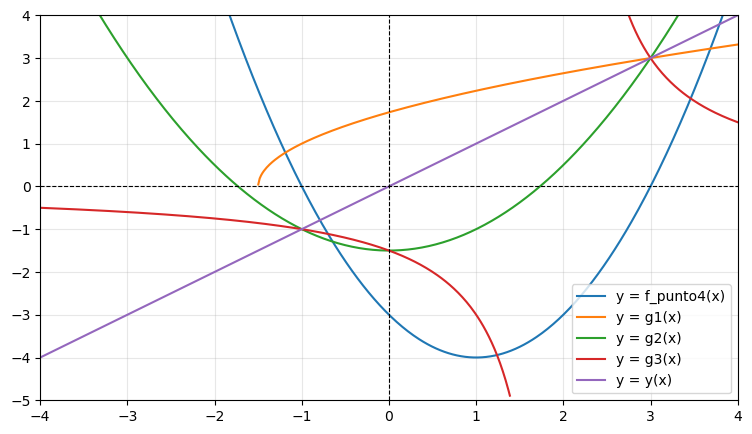

In [17]:
# Grafica de las funciones
import no_lineales as nl
def y(x):
    return x
nl.graficar([f_punto4, g1, g2, g3,y], -4, 4, y_lim=(-5,4), y_tope=5)

# 5) La función f(x) = x^2 + x - 1 tiene una raíz en x = 0.6180339.

In [18]:
# a
def f_punto5(x):
    return np.float32(x**2 + x -1)

def g1_punto5(x):
    return np.float32(1 / (x + 1))

def g2_punto5(x):
    return np.float32(-x**2 + 1)

def g3_punto5(x):
    return np.float32(np.sqrt(-1*x + 1))

def primera_visectriz(x):
    return x

x0 = 0.1
print(f"con x = {x0}")
print(f"la funcion G1 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g1_punto5)}")
print("- - - -")
print(f"la funcion G2 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g2_punto5)}")
print("- - - -")
print(f"la funcion G3 converge a: {Punto_Fijo(np.float32(x0), np.float32(eps), maxIte, g3_punto5)}")
print("")

# b
x0 = 1
print(f"Para x = {x0} la funcion g1(x) = 1/(x+1)")
import no_lineales as nl
nl.punto_fijo(x0,g1_punto5)
print("- - - -")

con x = 0.1
Termino con 9 iteraciones
0.6181507
la funcion G1 converge a: 0.6181507110595703
- - - -
Termino con 101 iteraciones
1.0
la funcion G2 converge a: Diverge
- - - -
Termino con 35 iteraciones
0.61840886
la funcion G3 converge a: 0.6184088587760925

Para x = 1 la funcion g1(x) = 1/(x+1)
It=2 | x0=1 | x1=0.5 | error=0.5
It=3 | x0=0.5 | x1=0.6666666865348816 | error=0.1666666865348816
It=4 | x0=0.6666666865348816 | x1=0.5999999642372131 | error=0.06666672229766846
It=5 | x0=0.5999999642372131 | x1=0.6250000596046448 | error=0.02500009536743164
It=6 | x0=0.6250000596046448 | x1=0.6153846383094788 | error=0.009615421295166016
It=7 | x0=0.6153846383094788 | x1=0.6190476417541504 | error=0.003663003444671631
It=8 | x0=0.6190476417541504 | x1=0.6176470518112183 | error=0.001400589942932129
It=9 | x0=0.6176470518112183 | x1=0.6181818246841431 | error=0.0005347728729248047
Raíz encontrada en x=0.6181818246841431
- - - -


[i] Información: el tope indicado es mayor al límite de abscisas indicado, puede ser ignorado


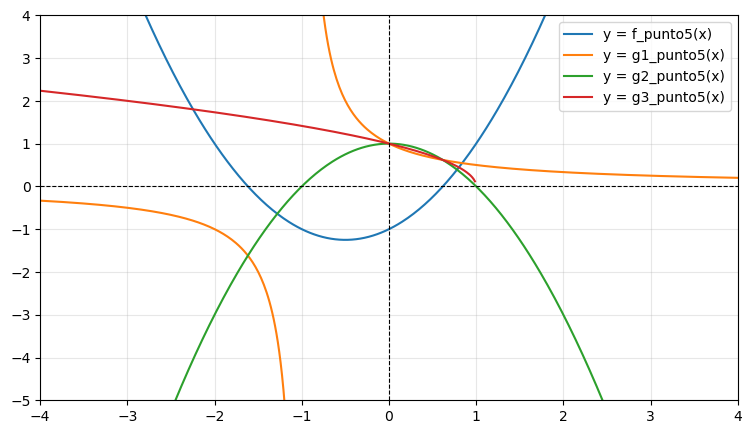

In [43]:
import no_lineales as nl
nl.graficar([f_punto5, g1_punto5, g2_punto5, g3_punto5], -4, 4, y_lim=(-5,4), y_tope=6)
x = np.linspace(-5,5, 100, dtype=np.float32)

In [19]:
# c
x0 = 1
print(f"Para x = {x0} la funcion g1(x) = 1/(x+1)")
nl.steffensen(x0,g1)
print("- - - -")

Para x = 1 la funcion g1(x) = 1/(x+1)
It=1 | x0=1 | x1=2.2360680103302 | x2=2.733520746231079 | xs=3.068552017211914 | error=0.33503127098083496
It=2 | x0=3.068552017211914 | x1=3.022764205932617 | x2=3.0075786113739014 | xs=3.0000431537628174 | error=0.007535457611083984
It=3 | x0=3.0000431537628174 | x1=3.000014305114746 | x2=3.000004768371582 | xs=3.0 | error=4.76837158203125e-06
Raíz encontrada en x=3.0
- - - -


# 6) no_lineales

Metodo de Biseccion:
Raíz encontrada en x=-0.70751953125
- - - -
Metodo Regula Falsi
Raíz encontrada en x=0.0
- - - -
Metodo Secante:
Raíz encontrada en x=0.7071069478988647
- - - -
Metodo Newton-Raphson
Raíz encontrada en x=0.7071067690849304
- - - -
Metodo Newton-Raphson Modificado
Raíz encontrada en x=-0.7071067690849304
- - - -
Metodo Punto Fijo
Raíz encontrada en x=4.547473508864641e-13
- - - -
Metodo Steffensen
Raíz encontrada en x=0.7071068286895752
- - - -
Grafica de f(x)=2x^3 - x
[i] Información: el tope indicado es mayor al límite de abscisas indicado, puede ser ignorado


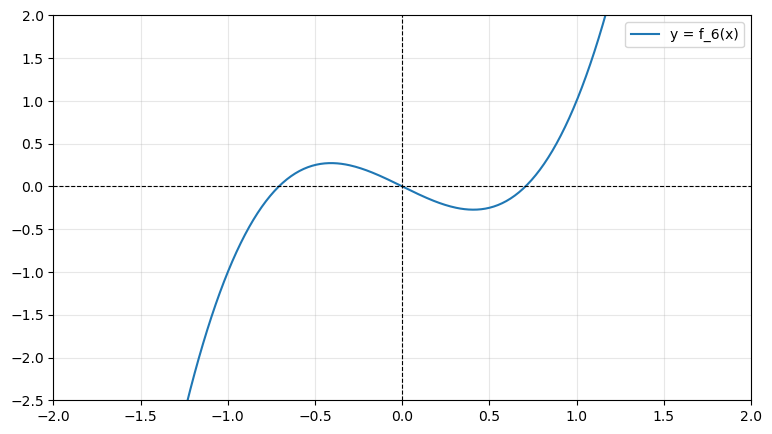

In [53]:
import no_lineales as nl
import numpy as np

def f_6(x):
    return np.float32(2 * x**3 - x)

def df_6(x):
    return np.float32(6 * x**2 - 1)

def df2_6(x):
    return np.float32(12 * x)

def g_6(x):
    return np.float32(2 * x**3)

print("Metodo de Biseccion:")
nl.biseccion(-2,2,f_6, debug=False)
print("- - - -")
print("Metodo Regula Falsi")
nl.Regula_Falsi(-2,2,f_6,1e-03,100,False)
print("- - - -")
print("Metodo Secante:")
nl.secante(1.5,2,f_6, 100,1e-03,False)
print("- - - -")
print("Metodo Newton-Raphson")
nl.newton_raphson(1.5,f_6,df_6,1e-3,100,False)
print("- - - -")
print("Metodo Newton-Raphson Modificado")
nl.newton_raphson_modificado(-0.5,f_6,df_6,df2_6,1e-03,100,False)
print("- - - -")
print("Metodo Punto Fijo")
nl.punto_fijo(0.5,g_6,1e-03,100,False)
print("- - - -")
print("Metodo Steffensen")
nl.steffensen(1,g_6,1e-03,100,False)
print("- - - -")
print("Grafica de f(x)=2x^3 - x")
nl.graficar([f_6], -2, 2 ,y_lim=(-2.5, 2), y_tope=6)
